In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, "/home/lilianae/projects/naf_clean")

parent_folder = str(Path.cwd().parents[0])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)

from sigpy import mri
from sigpy.mri import dcf

import scipy
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import sigpy as sp
import cupy as cp
import numpy as np


## My files
import save_data_helpers
from ksp_plot_helpers import plot_ksp_data_multichannel
import recon_functions
import recon_plot_helpers
import raw_data_utils
import coil_utils
from admm.utils_moco import golden_angle_coords_3d
from custom_recons.created_app import TotalVariationRecon_Stacked

## 1. Load data 

Load non-cartesian k-space data. It should be formatted as: (num_channels, num_slices, num_spokes, num_readouts).

In [2]:
ksp_512 = save_data_helpers.read_pickle('/home/lilianae/projects/naf_clean/load_data_clean/subject3_mid0283/patient3_mid0283_ksp_from_mdb_512_samples.pkl')
ksp_512 = np.transpose(ksp_512, (2, 0, 1, 3))
print(f'ksp_512.shape = {ksp_512.shape}')

ksp_512.shape = (15, 58, 2002, 512)


Validate center of k-space via average magnitude

In [3]:
# Average magnitude across all coils, slices, spokes
mean_profile = np.mean(np.abs(ksp_512), axis=(0, 1, 2))  # shape: (num_readouts,)
center_estimate = np.argmax(mean_profile)
print(f"Estimated center readout: {center_estimate}")

Estimated center readout: 256


## 2. Take first 1000 spokes

For fully sampled radial k-space data (~2000 spokes), undersample to first 1000 spokes.

In [4]:
oshape = (58, 32, 32)
num_spokes = 300
ksp_reduced_spokes = ksp_512[:, :, :num_spokes, :]
print(f'ksp_reduced_spokes.shape = {ksp_reduced_spokes.shape}')

ksp_reduced_spokes.shape = (15, 58, 300, 512)


## 3. Zero-pad edges of k-space

In [5]:
## To make low res, use full 512 spoke but zero out edges (crop data but not matrix)
def zero_pad_kspace(kspace, num_readouts_to_keep, center_readout=None):
    '''Given k-space matrix representing radial acquisition, keep
    middle readouts from each spoke and zero out edges. Output k-space
    is the same shape, with edges zeroed.

    Inputs
    -------------------------------
    kspace: ndarray
        K-space array of shape (num_coils, num_slices, num_spokes, num_readouts)
    num_readouts_to_keep: int
        Number of central readouts to keep
    center_readout: int, optional
        Index of the center readout. Default ==  num_readouts // 2.

    Output
    ------------------------------
    kspace_zeroed_edges: ndarray
        K-space array of shape (num_coils, num_slices, num_spokes, num_readouts),
        with edges zeroed out.
    '''
    num_readouts = kspace.shape[-1]

    if center_readout is None:
        center_readout = num_readouts // 2

    start = center_readout - num_readouts_to_keep // 2
    end   = start + num_readouts_to_keep  # ensures exact count regardless of parity

    kspace_zeroed_edges = np.zeros_like(kspace)  # already complex if kspace is complex
    kspace_zeroed_edges[..., start:end] = kspace[..., start:end]

    return kspace_zeroed_edges
    

## 3. Apodization using Fermi-Dirac

In [6]:
def fermi_window(num_readouts, num_readouts_to_keep, center_readout=None, width=5.0):
    """
    Create Fermi-Dirac apodization window for a radial spoke.
    
    Parameters
    ----------
    num_readouts: int
        Total number of readout points (last dim of k-space data)
    num_readouts_to_keep  int
        Number of central readouts to keep 
    center_readout: int, optional
        Default is num_readouts // 2
    width : float
        Transition width in readout samples, larger = smoother rolloff
    
    Returns
    -------
    window : ndarray, shape (num_readouts,)
        Symmetric Fermi window, 1 at center, rolling off to 0 at edges
    """
    if center_readout is None:
        center_readout = num_readouts // 2

    # For each RO index, get radial distance from k-space center
    indices = np.arange(num_readouts)

    r = np.abs(indices - center_readout)  # distance from center (0 at DC)

    # set cutoff radius r0 = num_readouts_to_keep//2
    r0 = num_readouts_to_keep / 2.0

    # Fermi-Dirac: 1 near center, smooth rolloff to 0 at r0
    window = 1.0 / (1.0 + np.exp((r - r0) / width))

    return window


def apply_fermi_window(kspace, num_readouts_to_keep, center_readout=None, width=5.0):
    """
    Apply Fermi-Dirac apodization to k-space along readouts

    Parameters
    ----------
    kspace: ndarray, shape (num_coils, num_slices, num_spokes, num_readouts)
    num_readouts_to_keep: int
    center_readout: int, optional
    width: float
        Fermi transition width in samples

    Returns
    -------
    kspace_apodized : ndarray, same shape as kspace
    """
    num_readouts = kspace.shape[-1]

    window = fermi_window(num_readouts, num_readouts_to_keep, 
                          center_readout, width)

    # Broadcast over (num_coils, num_slices, num_spokes) since this is only applied over readout axis
    return kspace * window[np.newaxis, np.newaxis, np.newaxis, :]

In [7]:
kspace_zeroed_edges = zero_pad_kspace(ksp_reduced_spokes, num_readouts_to_keep=10,
                                      center_readout=256)

kspace_fermi_window = apply_fermi_window(ksp_reduced_spokes, num_readouts_to_keep=10,
                                      center_readout=256, width=2.0)

print(f'kspace_zeroed_edges.shape = {kspace_zeroed_edges.shape}')
print(f'kspace_fermi_window.shape = {kspace_fermi_window.shape}')

kspace_zeroed_edges.shape = (15, 58, 300, 512)
kspace_fermi_window.shape = (15, 58, 300, 512)


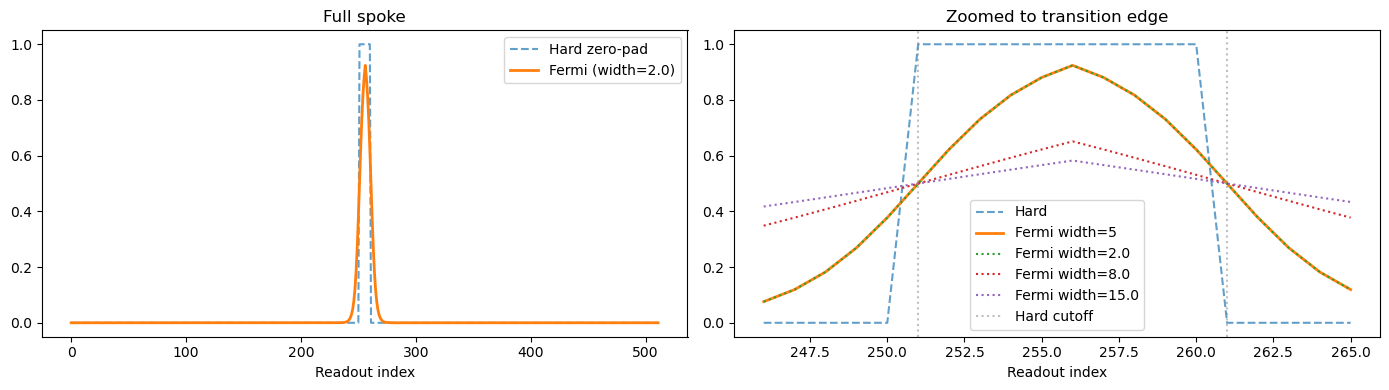

In [8]:
num_readouts = ksp_reduced_spokes.shape[-1]
num_readouts_to_keep = 10
center_readout = 256
width = 2.0
# Generate windows for comparison
window_fermi = fermi_window(num_readouts, num_readouts_to_keep, center_readout, width=width)
window_rect  = zero_pad_kspace(np.ones((1,1,1,num_readouts)), num_readouts_to_keep, center_readout)[0,0,0,:]

readouts = np.arange(num_readouts)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))


axes[0].plot(readouts, window_rect,  label='Hard zero-pad', linestyle='--', alpha=0.7)
axes[0].plot(readouts, window_fermi, label=f'Fermi (width={width})',     linewidth=2)
axes[0].set_title('Full spoke')
axes[0].set_xlabel('Readout index')
axes[0].legend()

start_ro = center_readout - num_readouts_to_keep
end_ro = center_readout + num_readouts_to_keep
axes[1].plot(readouts[start_ro:end_ro], window_rect[start_ro:end_ro],  linestyle='--', alpha=0.7, label='Hard')
axes[1].plot(readouts[start_ro:end_ro], window_fermi[start_ro:end_ro], linewidth=2,    label='Fermi width=5')

# Compare Fermi window widths
for w in [2.0, 8.0, 15.0]:
    w_fermi = fermi_window(num_readouts, num_readouts_to_keep, center_readout, width=w)
    axes[1].plot(readouts[start_ro:end_ro], w_fermi[start_ro:end_ro], linestyle=':', label=f'Fermi width={w}')

axes[1].axvline(center_readout - num_readouts_to_keep//2, color='gray', linestyle=':', alpha=0.5, label='Hard cutoff')
axes[1].axvline(center_readout + num_readouts_to_keep//2, color='gray', linestyle=':', alpha=0.5)
axes[1].set_title('Zoomed to transition edge')
axes[1].set_xlabel('Readout index')
axes[1].legend()

plt.tight_layout()
plt.show()

### 2a. Double-check K-space apodization

After our non-Cartesian k-space has been cropped, do a quick NUFFT recon to verify that we performed cropping correctly

In [9]:
ncoils, nslices, nspokes, nsamples = kspace_fermi_window.shape
img_shape = (nslices, nsamples, nsamples)

coord = golden_angle_coords_3d(img_shape=img_shape, num_spokes=nspokes, num_points=nsamples)
dcf_ksp =  save_data_helpers.read_pickle(f"dcf_cropped_{nspokes}_spokes_30RO_{nslices}_slices.pkl")
# dcf_ksp = mri.pipe_menon_dcf(coord=coord, img_shape=img_shape, device=0)

# save_data_helpers.write_pickle(dcf_ksp, f"dcf_cropped_{nspokes}_spokes_30RO_{nslices}_slices.pkl")

coord_gpu = sp.to_device(coord, device=0)
dcf_ksp_gpu = dcf_ksp  # already on GPU

coil_images = np.zeros((ncoils, *img_shape), dtype=np.complex128)

for c in range(ncoils):
    print(f"Reconstructing coil {c+1}/{ncoils}...")
    
    # Move one coil to GPU, apply DCF, reconstruct
    ksp_coil = sp.to_device(kspace_fermi_window[c], device=0)  # (nslices, nspokes, nsamples)
    coil_img = sp.nufft_adjoint(ksp_coil * dcf_ksp_gpu, coord_gpu, oshape=img_shape)
    
    coil_images[c] = sp.to_device(coil_img, device=0).get()
    del ksp_coil, coil_img
    cp.get_default_memory_pool().free_all_blocks()  # aggressively free GPU cache

Reconstructing coil 1/15...
Reconstructing coil 2/15...
Reconstructing coil 3/15...
Reconstructing coil 4/15...
Reconstructing coil 5/15...
Reconstructing coil 6/15...
Reconstructing coil 7/15...
Reconstructing coil 8/15...
Reconstructing coil 9/15...
Reconstructing coil 10/15...
Reconstructing coil 11/15...
Reconstructing coil 12/15...
Reconstructing coil 13/15...
Reconstructing coil 14/15...
Reconstructing coil 15/15...


Show reconstructions

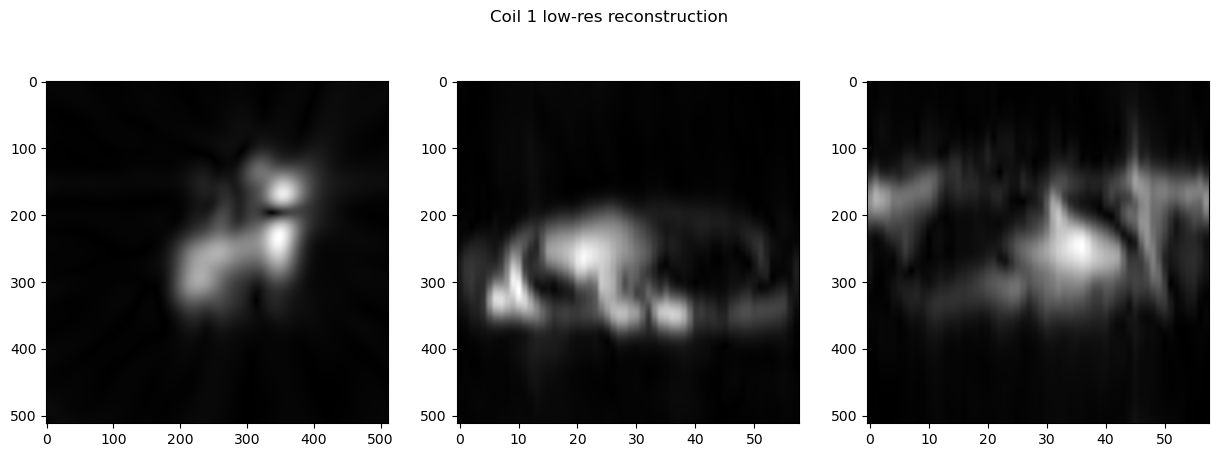

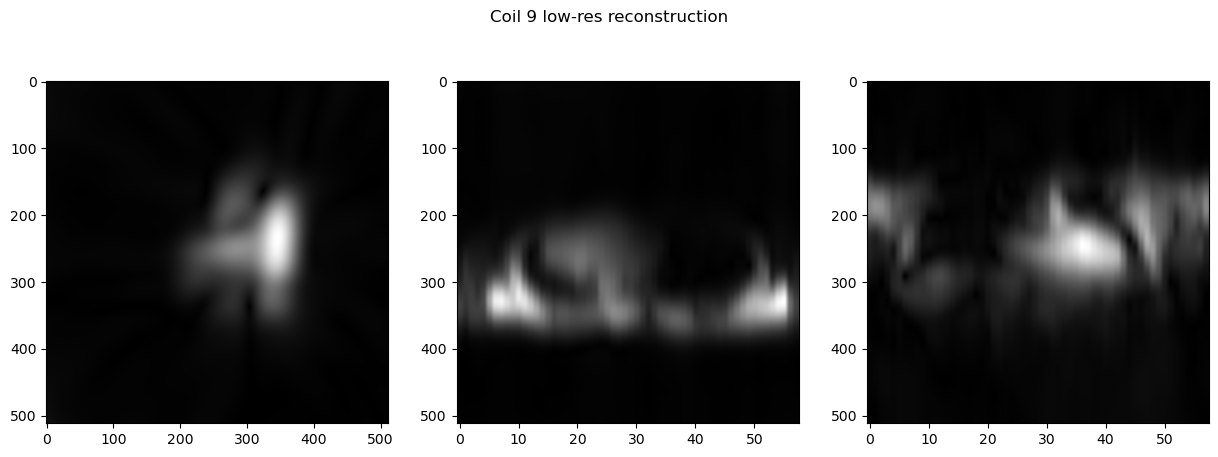

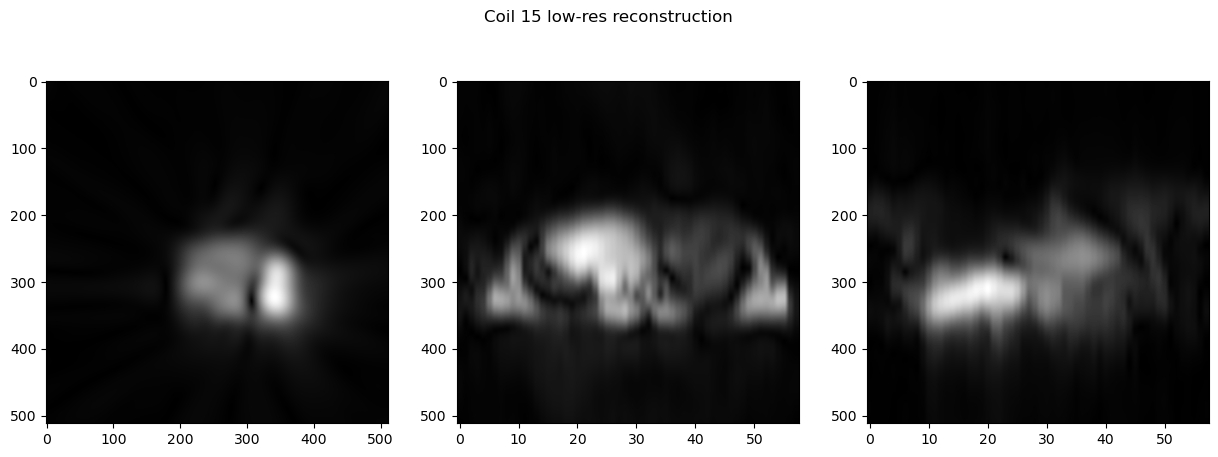

In [10]:
view_coils = [0, 8, 14]
for coil in view_coils:
    recon_plot_helpers.plot_recons_all_axes(coil_images[coil], title=f'Coil {coil+1} low-res reconstruction')

## 4. Run TotalVariation recon

Now with low-resolution radial k-space, run TotalVariation reconstruction for low res recon

In [11]:
def _stacked_nufft_operator_sens(img_shape, coords, mps):
    """setup a stacked 2D NUFFT sp operator acting on a 3D image
       the opeator first performs a 1D FFT along the "z" axis (0 or left-most axis)
       followed by applying 2D NUFFTS to all "slices"
       
    Parameters
    ----------
        img_shape: tuple
            shape of the image
        coords: (numpy or cupy) array 
            coordinates of the k-space samples
            shape (n_k_space_points,2)
            units: "unitless" -> -N/2 ... N/2 at Nyquist (sp convention)
        mps: (numpy or cupy) array
            sensitivity maps of shape (num_channels, *img_shape)

    Returns
    -------
        Diag: a stack of NUFFT operators
    """

    num_channels = len(mps)

    ft0_op = sp.linop.FFT(img_shape, axes=(0, ))

    # setup a 2D NUFFT operator for the start
    nufft_op = sp.linop.NUFFT(img_shape[1:], coords)


    # reshaping operator for input
    rs_in = sp.linop.Reshape(img_shape[1:], (1, ) + img_shape[1:])
    # setup a list of "n" 2D NUFFT operators (one per slice)
    ops = []
    for i in range(img_shape[0]):
        coords_i = coords[i].reshape(-1, coords.shape[-1])[:, 1:]  # (400*512, 2)
        nufft_op_i = sp.linop.NUFFT(img_shape[1:], coords_i)
        # Reshape NUFFT output from flat to 2D: (400*512,) -> (400, 512)
        rs_nufft = sp.linop.Reshape((coords.shape[1], coords.shape[2]), nufft_op_i.oshape)
        rs_out_i = sp.linop.Reshape((1, coords.shape[1], coords.shape[2]), (coords.shape[1], coords.shape[2]))
        ops.append(rs_out_i * rs_nufft * nufft_op_i * rs_in)


    # apply 2D NUFFTs to all "slices" using the sp Diag operator
    full_op= sp.linop.Diag(ops, iaxis=0, oaxis=0) * ft0_op
    #### Combine Sensitivity Op (mult with sens) and respective ft0+nuFFT op:

    #sensitivity = np.ones((num_channels,*img_shape),dtype=np.complex64)
    S = sp.linop.Multiply(img_shape,mps)

    rs_in_sense = sp.linop.Reshape(img_shape,(1,)+img_shape)
    rs_out_sense = sp.linop.Reshape((1,)+tuple(full_op.oshape),full_op.oshape)
    return  sp.linop.Diag(num_channels*[rs_out_sense*full_op*rs_in_sense],iaxis=0,oaxis=0)*S

In [12]:
img_shape = (58, 512, 512)
device = 0
num_coils, num_slices, num_spokes, num_readouts = kspace_fermi_window.shape

with cp.cuda.Device(device):
    low_res_recons = np.zeros((num_coils, *img_shape), dtype=np.complex64)  # CPU
    
    for i in range(num_coils):
        print(f"\rPre-initialization: TV recon for coil {i+1}/{num_coils}", end='', flush=True)
        
        # Add coil dim: (slices, spokes, readouts) -> (1, slices, spokes, readouts)
        ksp_coil = sp.to_device(kspace_fermi_window[i][np.newaxis, ...], device=0)
        y_coil = ksp_coil * dcf_ksp_gpu[np.newaxis, ...]  # dcf also needs coil dim
        
        tv_preinit_alg = TotalVariationRecon_Stacked(
            y=y_coil,
            mps=np.ones((1, *img_shape), dtype=np.complex128),   # (1, 58, 512, 512) -> img_shape = (58, 512, 512)
            lamda=0,
            coord=coord_gpu,
            device=device,
            z=None,
            max_iter=50,
            max_power_iter=10,
            show_pbar=True
        )
        
        result = tv_preinit_alg.run()  # shape: (58, 512, 512)
        low_res_recons[i] = sp.to_device(result, sp.cpu_device)  # move to CPU 
        
        del tv_preinit_alg, ksp_coil, y_coil, result
        cp.get_default_memory_pool().free_all_blocks()

Pre-initialization: TV recon for coil 1/15

MaxEig:   0%|          | 0/10 [00:00<?, ?it/s]

TotalVariationRecon_Stacked:   0%|          | 0/50 [00:00<?, ?it/s]

Pre-initialization: TV recon for coil 2/15

MaxEig:   0%|          | 0/10 [00:00<?, ?it/s]

...

MaxEig:   0%|          | 0/10 [00:00<?, ?it/s]

TotalVariationRecon_Stacked:   0%|          | 0/50 [00:00<?, ?it/s]

Pre-initialization: TV recon for coil 15/15

MaxEig:   0%|          | 0/10 [00:00<?, ?it/s]

TotalVariationRecon_Stacked:   0%|          | 0/50 [00:00<?, ?it/s]

In [13]:
print(low_res_recons.shape)

(15, 58, 512, 512)


View low-resolution maps

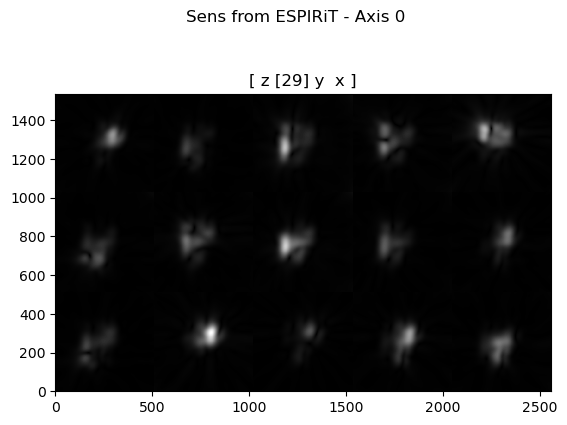

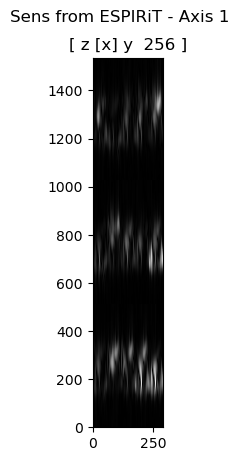

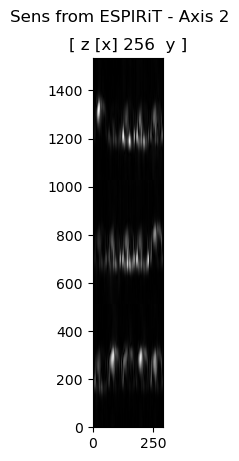

In [14]:
import sigpy.plot as pl

pl.ImagePlot(low_res_recons, z=0, title='Sens from ESPIRiT - Axis 0')
pl.ImagePlot(low_res_recons, x=1, y=2, z=0, title='Sens from ESPIRiT - Axis 1')
pl.ImagePlot(low_res_recons, x=1, y=3, z=0, title='Sens from ESPIRiT - Axis 2')

## 5. Divide individual coil images by RSS

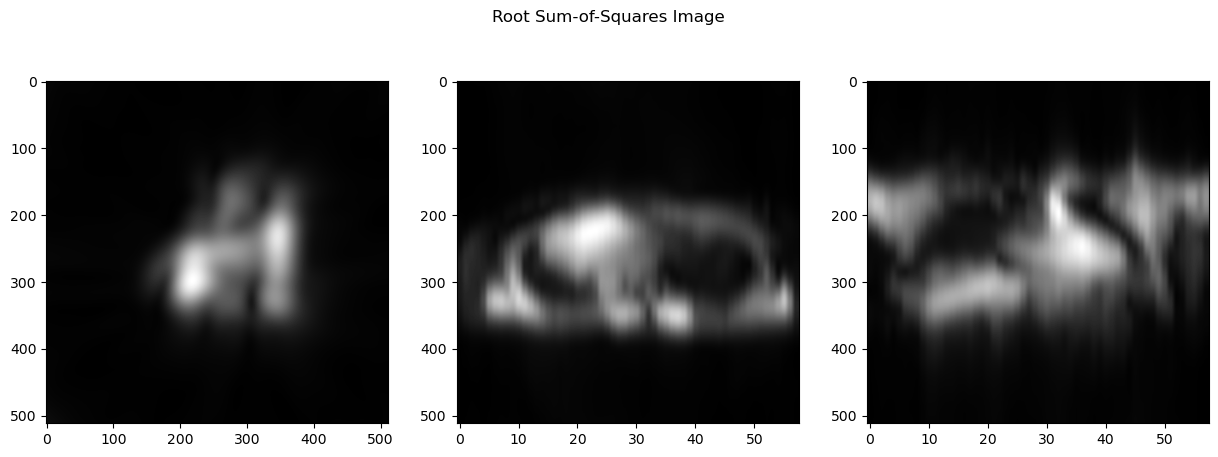

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [15]:
rss_coil_image = sp.rss(low_res_recons, axes=0)
recon_plot_helpers.plot_recons_all_axes(rss_coil_image, title='Root Sum-of-Squares Image')

In [16]:
def get_coil_sensitivities(coil_images, rss_image, threshold=0.04):
    """
    threshold: fraction of max RSS to use as cutoff (0.05 = 5% of max signal)
               increase if background artifacts still leak in
    """
    # Build mask from RSS — only keep voxels with meaningful signal
    mask = rss_image > (threshold * rss_image.max())
    
    # Safe division — only divide inside mask
    rss_safe = np.where(mask, rss_image, 1.0)  # replace 0s with 1 to avoid div/0
    normalized = coil_images / rss_safe[np.newaxis, ...]
    
    # Zero out background
    normalized = normalized * mask[np.newaxis, ...]
    
    return np.conj(normalized)
# def get_coil_sensitivities(coil_images, rss_image):
#     # Add small epsilon to avoid division by zero in background
#     normalized_coil_images = coil_images / (rss_image[np.newaxis, ...] + 1e-8)
#     return np.conj(normalized_coil_images)

coil_sensitivities = get_coil_sensitivities(low_res_recons, rss_image=rss_coil_image)

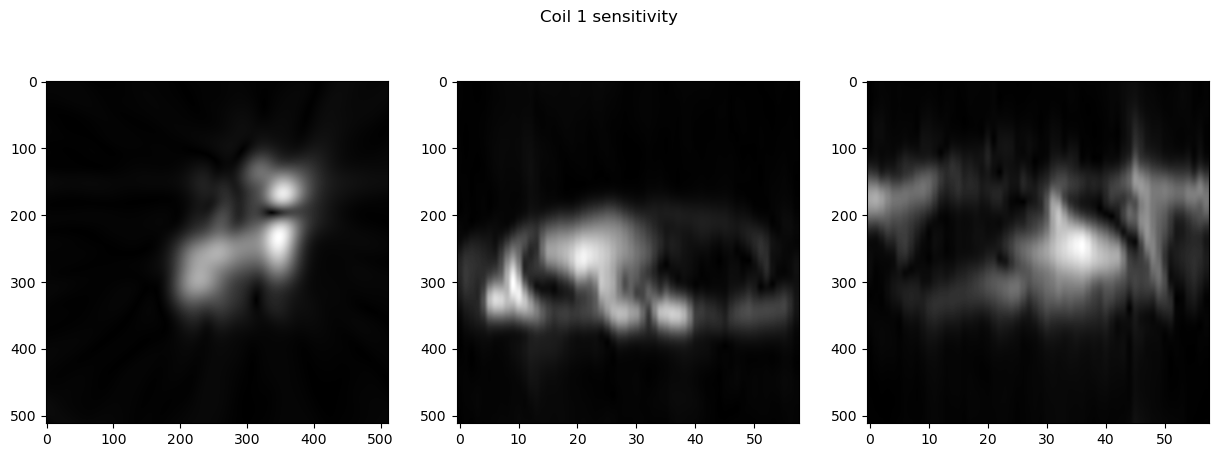

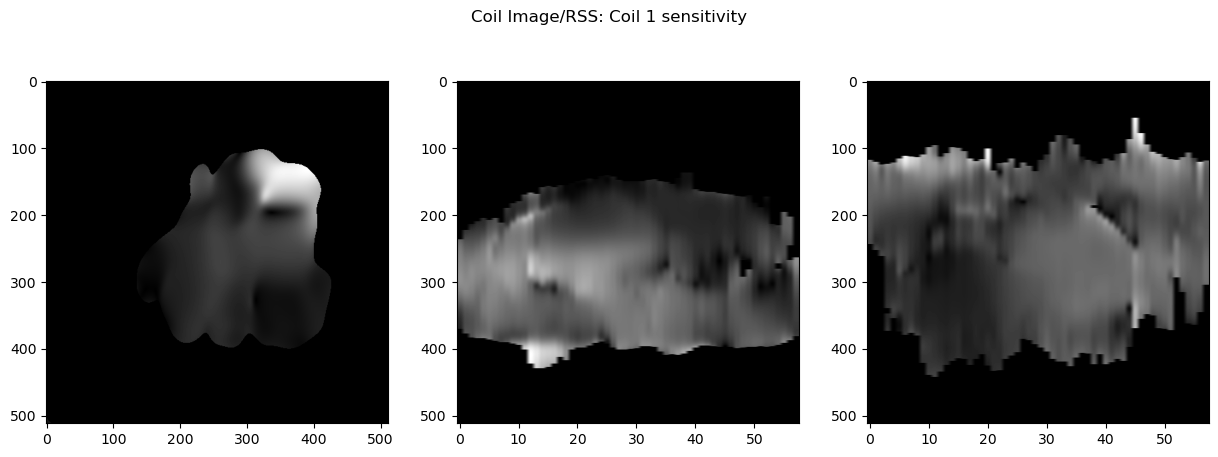

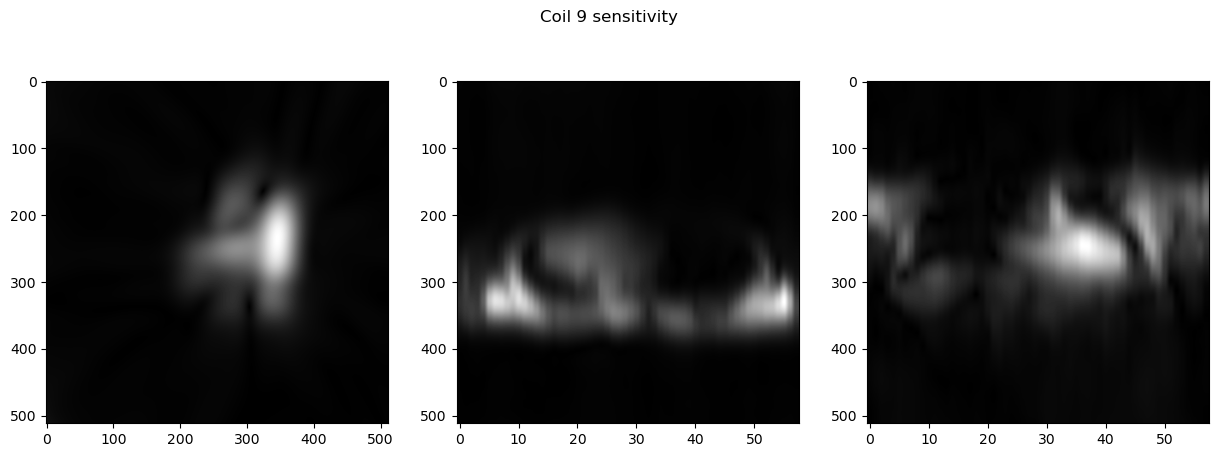

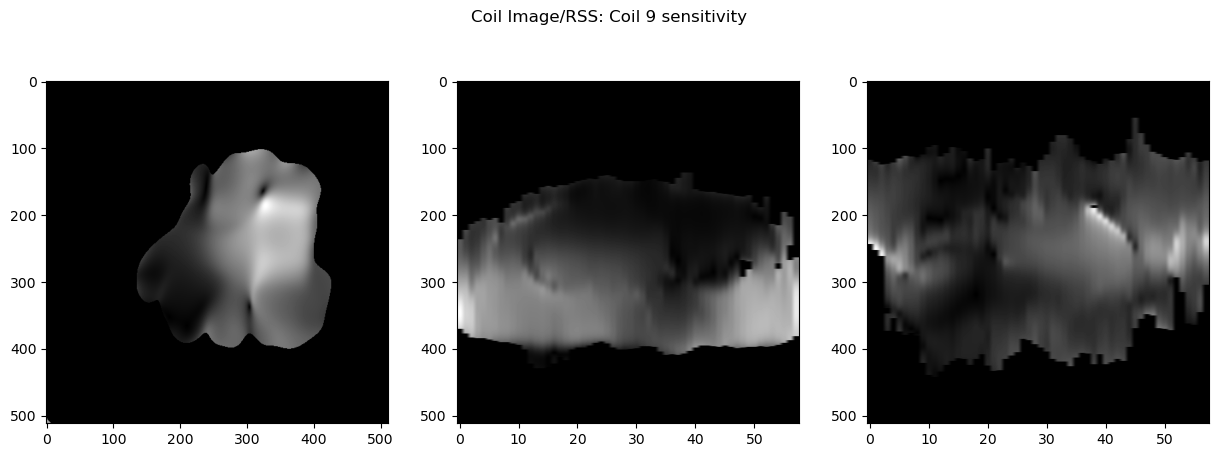

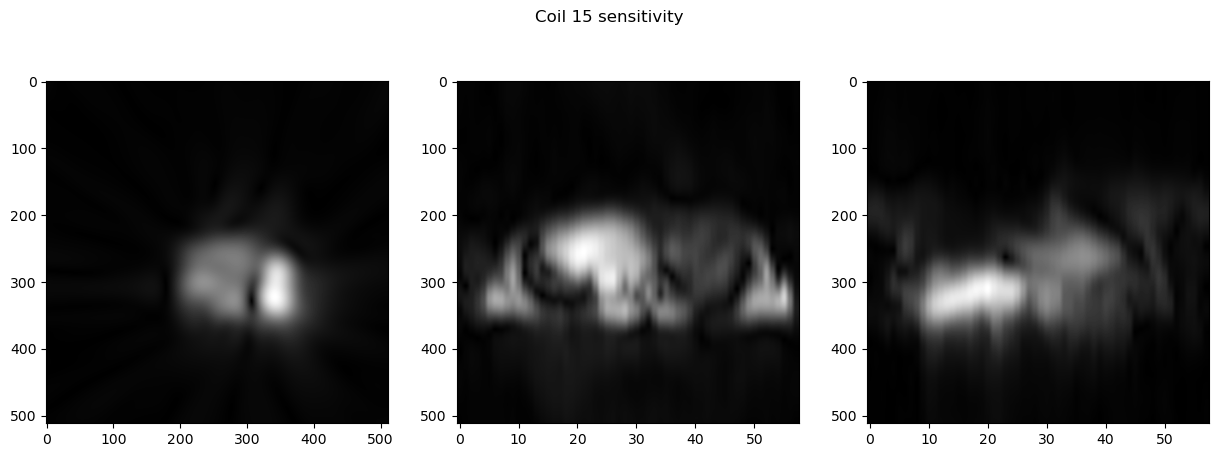

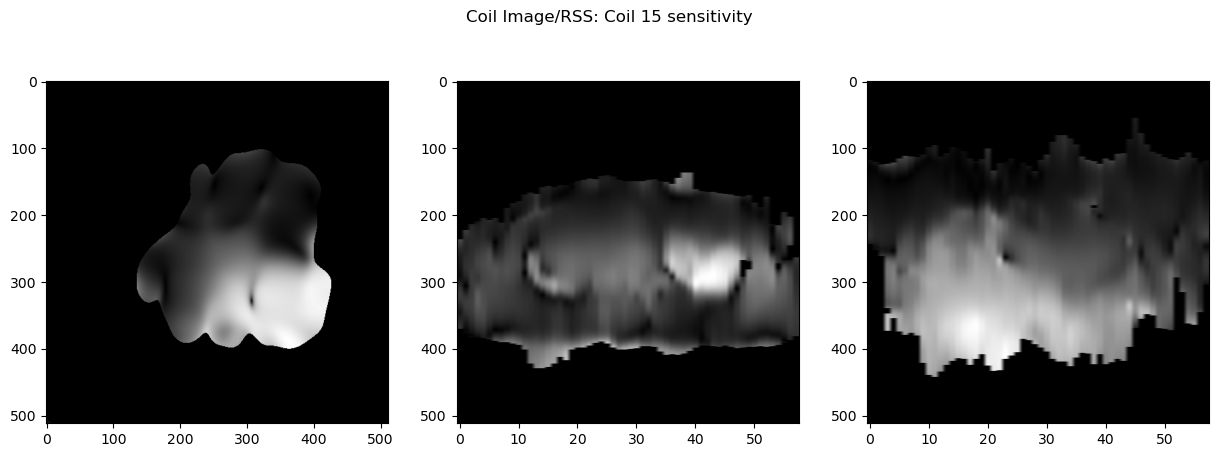

In [17]:
# coil_images_gridded = sp.ifft(ksp_gridded_array)
view_coils = [0, 8, 14]
for coil in view_coils:
    recon_plot_helpers.plot_recons_all_axes(low_res_recons[coil], title=f'Coil {coil+1} sensitivity')
    recon_plot_helpers.plot_recons_all_axes(coil_sensitivities[coil], title=f'Coil Image/RSS: Coil {coil+1} sensitivity')

In [18]:
coil_sens_conj = np.zeros_like(coil_sensitivities, dtype=np.complex128)
num_coils = coil_sensitivities.shape[0]

for c in range(num_coils):
    coil_sens_conj[c] = np.conjugate(coil_sensitivities[c])

print(coil_sens_conj.shape)

(15, 58, 512, 512)


## 5. Interpolate low-resolution maps to full resolution

Coil sensitivity maps will be same size as low-resolution Cartesian k-space. However, our original k-space data produces recons of a larger matrix size. Interpolate these low resolution maps to match the size of our full resolution recons

In [19]:
from scipy.ndimage import zoom, binary_fill_holes

def mps_reshape(mps, oshape, threshold=0.01, blur_sigma=(3.0, 4.0, 4.0)):
    ncoils = len(mps)
    Nz, Ny, Nx = mps[0].shape
    new_Nz, new_Ny, new_Nx = oshape
    zoom_factors = [new_Nz/Nz, new_Ny/Ny, new_Nx/Nx]
    mps_reshaped = np.zeros((ncoils, *oshape), dtype=complex)

    # Build mask from RSS at LOW res, fill holes, then zoom to full res
    rss_low = np.sqrt(np.sum(np.abs(mps)**2, axis=0))  # (Nz, Ny, Nx)
    mask_low = rss_low > (threshold * rss_low.max())
    # Fill interior holes slice by slice
    for z in range(Nz):
        mask_low[z] = binary_fill_holes(mask_low[z])
    # Zoom mask to full res (nearest-neighbor to keep it binary)
    mask_full = zoom(mask_low.astype(float), zoom_factors, order=0) > 0.5

    for coil in range(ncoils):
        mag = np.abs(mps[coil])
        phase = np.angle(mps[coil])

        # 1. Fill gaps inside anatomy before blurring
        #    Use inpainting: replace masked-out interior with local mean
        mag_filled = np.where(mask_low, mag, 
                              scipy.ndimage.uniform_filter(mag, size=5))
        phase_filled = np.where(mask_low, phase,
                                scipy.ndimage.uniform_filter(phase, size=5))

        # 2. Blur AFTER filling (avoids smoothing hard edges into gaps)
        mag_blurred   = scipy.ndimage.gaussian_filter(mag_filled,   sigma=blur_sigma)
        phase_blurred = scipy.ndimage.gaussian_filter(phase_filled, sigma=(1.0, 1.5, 1.5))

        # 3. Zoom to full resolution
        new_mag   = zoom(mag_blurred,   zoom_factors)
        new_phase = zoom(phase_blurred, zoom_factors)

        # 4. Apply full-res mask to zero background
        mps_reshaped[coil] = new_mag * np.exp(1j * new_phase) * mask_full

    return mps_reshaped, mask_full  # return mask too, useful for recon


mps_reshaped = mps_reshape(coil_sens_conj, oshape=(58, 512, 512))
# print(f'mps_rehsaped.shape = {mps_reshaped.shape}')

In [ ]:
mps_reshaped_conj = np.zeros_like(mps_reshaped[0], dtype=np.complex128)
num_coils = mps_reshaped[0].shape[0]

for c in range(num_coils):
    mps_reshaped_conj[c] = np.conjugate(mps_reshaped[0][c])

print(mps_reshaped_conj.shape)

## 6. View all: NUFFT, Espirit (low res), Espirit (high res)

In [ ]:
view_coils = [0, 8, 14]

for coil in view_coils:
    fig, axs = recon_plot_helpers.plot_recons_all_axes(mps_reshaped_conj[coil], title=f'Coil {coil+1} Sensitivity (full-res)')   

In [ ]:
save_data_helpers.write_pickle(mps_reshaped_conj, "/home/lilianae/projects/naf_clean/coils/subject3_mid0283/coil_maps_TV_conj_full_res_ksp_512_ungated.pkl")